In [ ]:
# python3
# linear regression
# Vehicle CO2 detection
# Using scikit-learn

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import linear_model
import sklearn.metrics as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

%matplotlib inline

In [3]:
# Load Dataset
df = pd.read_csv('co2.csv')
df.head()



,engine,cylandr,fuelcomb,out1
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [4]:
df.describe()

,engine,cylandr,fuelcomb,out1
count,500.000000,500.000000,500.000000,500.000000
mean,3.600400,6.132000,12.476600,268.026000
std,1.478191,1.832291,3.943025,67.099673
min,1.000000,4.000000,4.800000,110.000000
25%,2.000000,4.000000,9.500000,217.000000
50%,3.600000,6.000000,11.650000,260.000000
75%,5.000000,8.000000,14.800000,317.000000
max,6.800000,12.000000,25.800000,488.000000


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   engine    500 non-null    float64
 1   cylandr   500 non-null    int64  
 2   fuelcomb  500 non-null    float64
 3   out1      500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB


In [ ]:
# Exploratory Data Analysis (EDA)

<Axes: xlabel='out1', ylabel='count'>

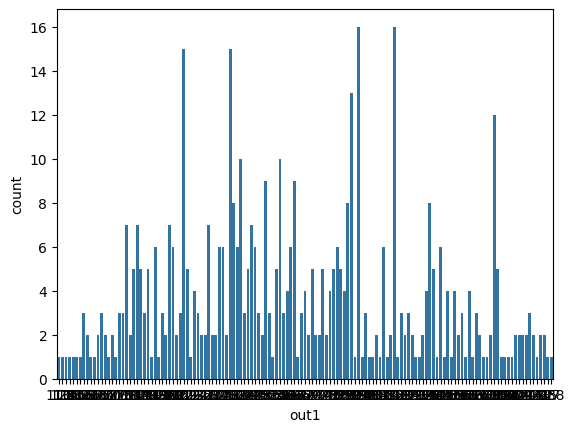

In [6]:
sns.countplot(x='out1' , data=df)

<Axes: xlabel='out1', ylabel='Count'>

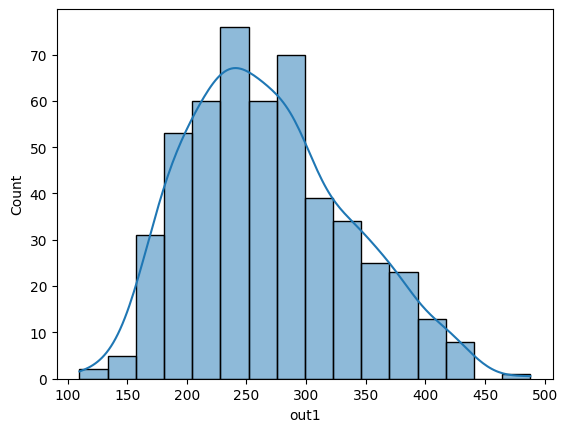

In [7]:
# Plotting the distribution of the target variable 'out1'
sns.histplot(df['out1'], kde=True)


<Axes: >

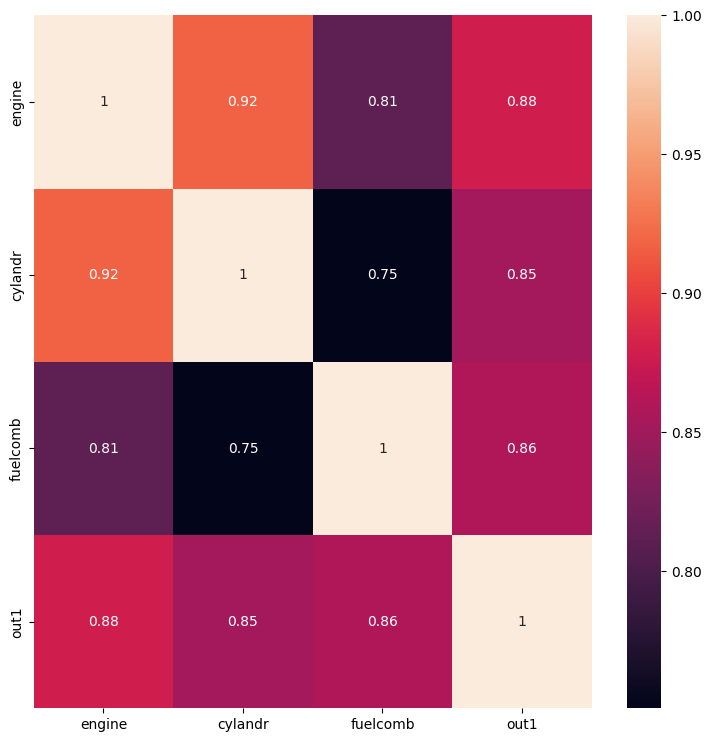

In [8]:
# we want drwing heatmap
plt.subplots(figsize=(9,9))
sns.heatmap(df.corr(),annot=True)

In [9]:
# Specify (x,y)
# Feature & Target Separation
x = df.drop("out1",axis=1)
y = df.out1


In [11]:
print(x,y)

     engine  cylandr  fuelcomb
0       2.0        4       8.5
1       2.4        4       9.6
2       1.5        4       5.9
3       3.5        6      11.1
4       3.5        6      10.6
..      ...      ...       ...
495     1.5        4       6.9
496     1.5        4       7.5
497     1.5        4       7.7
498     3.5        6      10.6
499     3.6        6      10.8

[500 rows x 3 columns] 0      196
1      221
2      136
3      255
4      244
      ... 
495    159
496    172
497    177
498    244
499    246
Name: out1, Length: 500, dtype: int64


In [12]:
# For splite x and y as train becuase we should trained some of (x) not all
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [13]:

print(x_train.shape, y_train.shape)

(400, 3) (400,)


In [14]:
# Model Training (Linear Regression)
model = linear_model.LinearRegression()

In [15]:
# Fit the model   
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Predictions
y_test_pred = model.predict(x_test)

In [17]:
#  Model Evaluation
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Model Evaluation Metrics")
print("------------------------")
print(f"R2 Score : {r2:.3f}")
print(f"MAE      : {mae:.3f}")
print(f"RMSE     : {rmse:.3f}")


Model Evaluation Metrics
------------------------
R2 Score : 0.859
MAE      : 20.270
RMSE     : 26.738


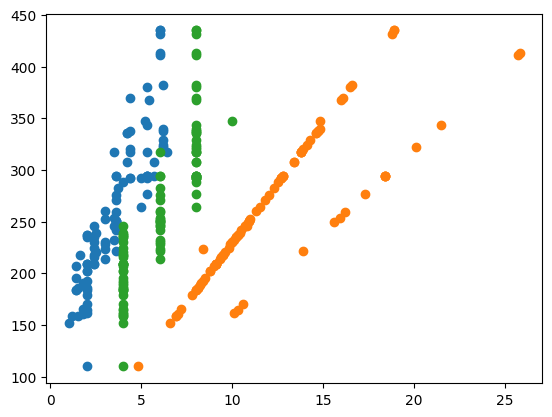

In [ ]:
# plt.scatter(x_test.engine,y_test)
# plt.scatter(x_test.fuelcomb,y_test)
# plt.scatter(x_test.cylandr,y_test)


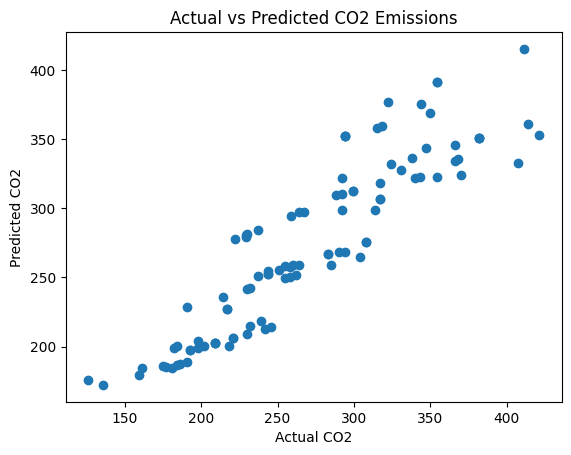

In [26]:
# Actual vs Predicted Visualization
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2 Emissions")
plt.show()


In [22]:
y_test_pred = model.predict(x_test)

In [23]:
y_test_pred

array([267.68086236, 274.47034635, 205.52472359, 295.4575153 ,
       189.45896179, 411.06779536, 372.24518582, 350.01461996,
       198.39979086, 207.67606867, 202.70248103, 265.33868414,
       296.80349232, 214.13010392, 257.45041883, 236.36485184,
       336.38943443, 336.38943443, 299.04309044, 295.64834844,
       311.29040847, 319.13245622, 192.1828063 , 317.02732869,
       257.45041883, 321.04078766, 213.45920644, 289.00348005,
       185.49172036, 322.33040212, 336.38943443, 207.72228622,
       176.88634003, 373.39614763, 201.985366  , 201.26825097,
       291.54067348, 317.02732869, 259.60176392, 185.9196042 ,
       296.70091221, 348.29712166, 258.16753386, 317.02732869,
       373.39614763, 332.08674427, 258.358367  , 330.70469471,
       253.14772867, 331.80347603, 204.13671108, 176.97877513,
       350.54090184, 372.96826379, 176.97877513, 289.3893284 ,
       340.92917529, 238.51619692, 190.5577431 , 210.59074633,
       321.04078766, 194.52498453, 189.84062808, 251.52

In [24]:
x_test

,engine,cylandr,fuelcomb
399,3.5,6,12.8
385,3.7,6,13.4
320,2.4,4,8.8
147,3.6,6,16.5
490,1.8,4,7.6
...,...,...,...
95,3.0,6,10.0
379,5.0,8,14.6
494,1.5,4,6.3
59,3.0,6,12.4


In [25]:
y_test

399    294
385    308
320    202
147    264
490    175
      ... 
95     230
379    336
494    145
59     285
69     314
Name: out1, Length: 100, dtype: int64

In [20]:
sample = np.array([[5.2, 12.1, 15.6]])  # example input
predicted_co2 = model.predict(sample)

print("Predicted CO2 Emission:", predicted_co2)

Predicted CO2 Emission: [370.30337976]


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
p206 = np.array([[5.2, 12.1, 15.6]])   # example for prediction
co2 = model.predict(p206)
print(co2)


[370.30337976]


C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
sm.mean_squared_error(y_test,y_test_pred)

809.3632658489737